# ⚙️ NeuralRetail — Feature Engineering
## Amdox Technologies | Data Science & Analytics
---
### What this notebook does:
- Loads clean data from EDA
- Builds RFM (Recency, Frequency, Monetary) customer scores
- Creates lag features and rolling statistics for forecasting
- Creates date and time features for ML models
- Saves final feature datasets for model training

In [12]:
# ============================================================
# CELL 2: Import libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Libraries imported!")

✅ Libraries imported!


In [13]:
# ============================================================
# CELL 3: Load clean data saved from EDA notebook
# ============================================================

df = pd.read_csv('../data/online_retail_clean.csv', parse_dates=['InvoiceDate'])

print(f"✅ Clean data loaded!")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
display(df.head(3))

✅ Clean data loaded!
📊 Shape: 392,692 rows × 15 columns
📅 Date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,DayOfWeek,Hour,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,2,8,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,2,8,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,2,8,2010-12


In [14]:
# ============================================================
# CELL 4: RFM Score Calculation
# ============================================================
# RFM = Recency, Frequency, Monetary
# This tells us how valuable each customer is

# Reference date = 1 day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"📅 Reference date for Recency: {reference_date.date()}")

# Calculate RFM metrics per customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f"\n✅ RFM calculated for {len(rfm):,} customers")
print(f"\n📊 RFM Statistics:")
display(rfm.describe().round(2))

📅 Reference date for Recency: 2011-12-10

✅ RFM calculated for 4,338 customers

📊 RFM Statistics:


,CustomerID,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00,4338.00
mean,15300.41,92.54,4.27,2048.69
std,1721.81,100.01,7.70,8985.23
min,12346.00,1.00,1.00,3.75
25%,13813.25,18.00,1.00,306.48
50%,15299.50,51.00,2.00,668.57
75%,16778.75,142.00,5.00,1660.60
max,18287.00,374.00,209.00,280206.02


In [15]:
# ============================================================
# CELL 5: Assign RFM Scores (1-5 scale)
# ============================================================
# We divide each metric into 5 equal groups (quintiles)
# Score 5 = best, Score 1 = worst
# NOTE: For Recency, lower days = better, so we reverse it

# Recency score — lower recency days = better customer = higher score
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1], duplicates='drop').astype(int)

# Frequency score — higher frequency = better = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)

# Monetary score — higher spend = better = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

# Combined RFM Score (average of all three)
rfm['RFM_Score'] = (rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']) / 3

print("✅ RFM scores assigned!")
display(rfm.head(10))

✅ RFM scores assigned!


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,2.333333
1,12347,2,7,4310.00,5,5,5,5.000000
2,12348,75,4,1797.24,2,4,4,3.333333
3,12349,19,1,1757.55,4,1,4,3.000000
4,12350,310,1,334.40,1,1,2,1.333333
5,12352,36,8,2506.04,3,5,5,4.333333
6,12353,204,1,89.00,1,1,1,1.000000
7,12354,232,1,1079.40,1,1,4,2.000000
8,12355,214,1,459.40,1,1,2,1.333333
9,12356,23,3,2811.43,4,3,5,4.000000


In [16]:
# ============================================================
# CELL 6: Assign Customer Segments based on RFM Score
# ============================================================

def assign_segment(score):
    """Assign business segment label based on RFM score"""
    if score >= 4.5:
        return 'Champions'          # Best customers — buy often, recently, spend most
    elif score >= 4.0:
        return 'Loyal Customers'    # Buy regularly and spend well
    elif score >= 3.5:
        return 'Potential Loyalists'# Recent buyers with good frequency
    elif score >= 3.0:
        return 'At Risk'            # Used to buy but haven't recently
    elif score >= 2.0:
        return 'Hibernating'        # Low scores across all dimensions
    else:
        return 'Lost'               # Lowest scores — likely churned

rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)

# Show segment distribution
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

print("✅ Customer segments assigned!")
print("\n📊 Segment Distribution:")
display(segment_counts)

✅ Customer segments assigned!

📊 Segment Distribution:


,Segment,Count
0,Hibernating,1178
1,Lost,881
2,At Risk,678
3,Champions,647
4,Loyal Customers,607
5,Potential Loyalists,347


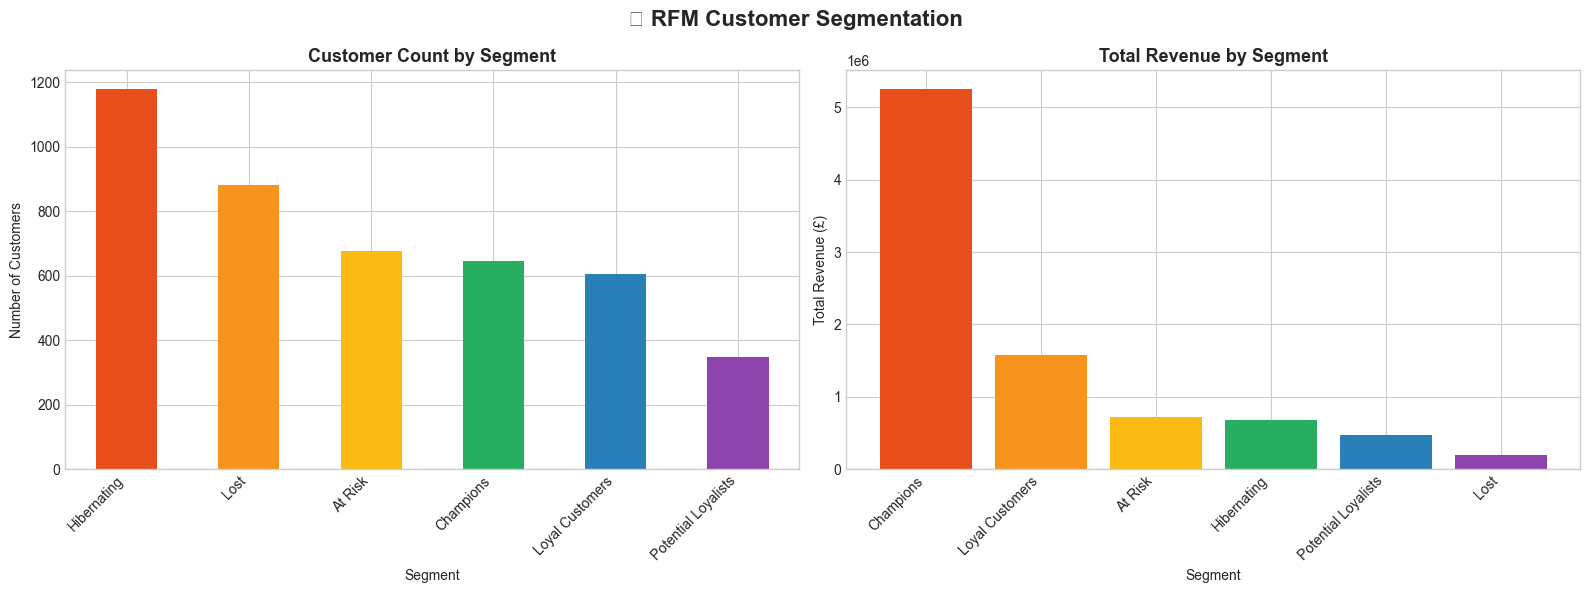

✅ Segment visualization saved!


In [17]:
# ============================================================
# CELL 7: Visualize Customer Segments
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — segment count
colors = ['#E84E1B', '#F7941D', '#FBBA13', '#27AE60', '#2980B9', '#8E44AD']
segment_counts.plot(
    kind='bar', x='Segment', y='Count',
    ax=axes[0], color=colors[:len(segment_counts)], legend=False
)
axes[0].set_title('Customer Count by Segment', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Right — revenue by segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
segment_revenue = segment_revenue.sort_values('Monetary', ascending=False)
axes[1].bar(segment_revenue['Segment'], segment_revenue['Monetary'],
            color=colors[:len(segment_revenue)])
axes[1].set_title('Total Revenue by Segment', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('👥 RFM Customer Segmentation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../evidently_reports/rfm_segments.png', dpi=150)
plt.show()
print("✅ Segment visualization saved!")

In [18]:
# ============================================================
# CELL 8: Create Daily Sales Time Series for Forecasting
# ============================================================
# We aggregate revenue per day — this will be used for
# demand forecasting with Prophet model

daily_sales = df.groupby(df['InvoiceDate'].dt.date).agg(
    Revenue     = ('TotalPrice', 'sum'),
    Orders      = ('InvoiceNo',  'nunique'),
    Items_Sold  = ('Quantity',   'sum')
).reset_index()

daily_sales.columns = ['Date', 'Revenue', 'Orders', 'Items_Sold']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])
daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)

print(f"✅ Daily sales created: {len(daily_sales)} days")
print(f"📅 From {daily_sales['Date'].min().date()} to {daily_sales['Date'].max().date()}")
display(daily_sales.head())

✅ Daily sales created: 305 days
📅 From 2010-12-01 to 2011-12-09


,Date,Revenue,Orders,Items_Sold
0,2010-12-01,46192.49,121,24114
1,2010-12-02,47197.57,137,31077
2,2010-12-03,23876.63,57,11798
3,2010-12-05,31361.28,87,16241
4,2010-12-06,31009.33,94,16115


In [19]:
# ============================================================
# CELL 9: Create Lag Features & Rolling Statistics
# ============================================================
# Lag features tell the model "what was the revenue X days ago"
# Rolling stats tell the model "what was the average over last X days"
# These are critical for time series forecasting

# Sort by date first
daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)

# --- Lag features ---
daily_sales['Revenue_Lag_1']  = daily_sales['Revenue'].shift(1)   # Yesterday
daily_sales['Revenue_Lag_7']  = daily_sales['Revenue'].shift(7)   # 1 week ago
daily_sales['Revenue_Lag_14'] = daily_sales['Revenue'].shift(14)  # 2 weeks ago
daily_sales['Revenue_Lag_30'] = daily_sales['Revenue'].shift(30)  # 1 month ago

# --- Rolling statistics ---
daily_sales['Rolling_Mean_7']  = daily_sales['Revenue'].rolling(window=7).mean()   # 7-day avg
daily_sales['Rolling_Mean_30'] = daily_sales['Revenue'].rolling(window=30).mean()  # 30-day avg
daily_sales['Rolling_Std_7']   = daily_sales['Revenue'].rolling(window=7).std()    # 7-day volatility

# --- Date features ---
daily_sales['DayOfWeek']  = daily_sales['Date'].dt.dayofweek    # 0=Mon, 6=Sun
daily_sales['Month']      = daily_sales['Date'].dt.month         # 1-12
daily_sales['Quarter']    = daily_sales['Date'].dt.quarter       # 1-4
daily_sales['IsWeekend']  = (daily_sales['DayOfWeek'] >= 5).astype(int)  # 1 if weekend

print("✅ Lag features and rolling statistics created!")
print(f"\n📋 New columns added:")
new_cols = ['Revenue_Lag_1','Revenue_Lag_7','Revenue_Lag_14','Revenue_Lag_30',
            'Rolling_Mean_7','Rolling_Mean_30','Rolling_Std_7',
            'DayOfWeek','Month','Quarter','IsWeekend']
for col in new_cols:
    print(f"   → {col}")

✅ Lag features and rolling statistics created!

📋 New columns added:
   → Revenue_Lag_1
   → Revenue_Lag_7
   → Revenue_Lag_14
   → Revenue_Lag_30
   → Rolling_Mean_7
   → Rolling_Mean_30
   → Rolling_Std_7
   → DayOfWeek
   → Month
   → Quarter
   → IsWeekend


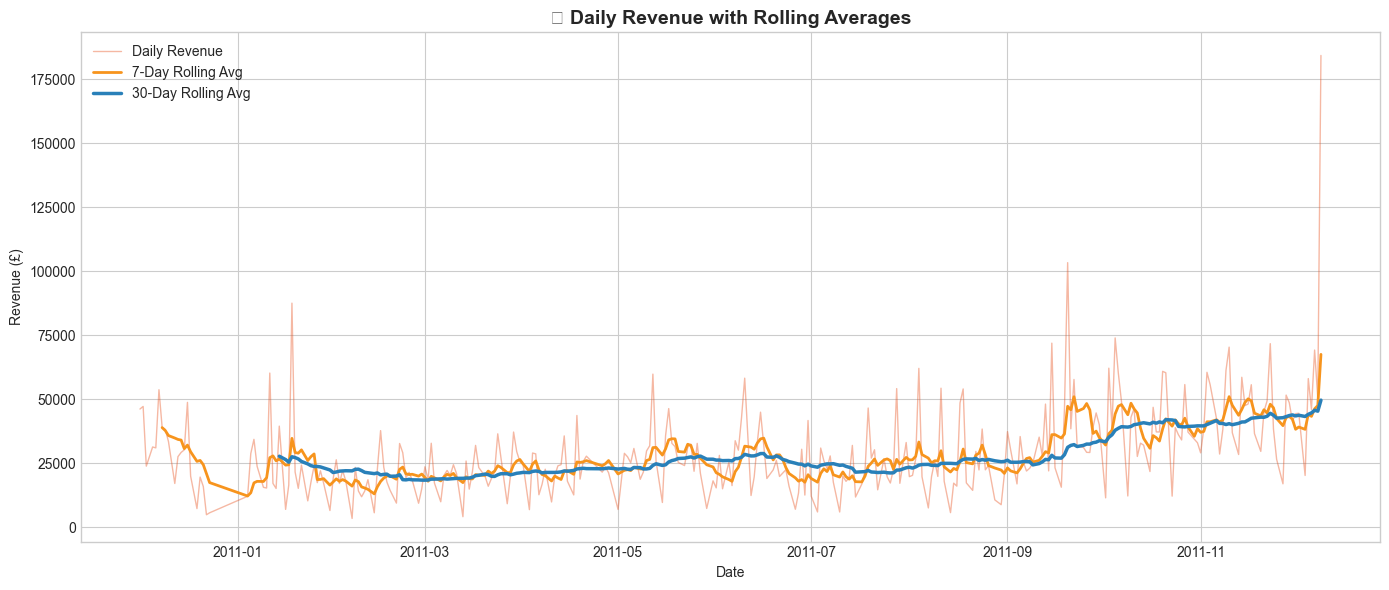

✅ Rolling averages chart saved!


In [20]:
# ============================================================
# CELL 10: Visualize Revenue with Rolling Averages
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Actual daily revenue
ax.plot(daily_sales['Date'], daily_sales['Revenue'],
        color='#E84E1B', alpha=0.4, linewidth=1, label='Daily Revenue')

# 7-day rolling average
ax.plot(daily_sales['Date'], daily_sales['Rolling_Mean_7'],
        color='#F7941D', linewidth=2, label='7-Day Rolling Avg')

# 30-day rolling average
ax.plot(daily_sales['Date'], daily_sales['Rolling_Mean_30'],
        color='#2980B9', linewidth=2.5, label='30-Day Rolling Avg')

ax.set_title('📈 Daily Revenue with Rolling Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.legend()
plt.tight_layout()
plt.savefig('../evidently_reports/rolling_averages.png', dpi=150)
plt.show()
print("✅ Rolling averages chart saved!")

In [21]:
# ============================================================
# CELL 11: Create Churn Label for ML Model
# ============================================================
# We define "churned" as a customer who hasn't bought
# in the last 90 days of the dataset period

# Last purchase date per customer
last_purchase = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
last_purchase.columns = ['CustomerID', 'LastPurchase']

# Dataset end date
end_date = df['InvoiceDate'].max()

# If last purchase was more than 90 days before end → churned = 1
last_purchase['DaysSinceLastPurchase'] = (end_date - last_purchase['LastPurchase']).dt.days
last_purchase['Churned'] = (last_purchase['DaysSinceLastPurchase'] > 90).astype(int)

# Merge churn label into RFM dataframe
rfm = rfm.merge(last_purchase[['CustomerID', 'Churned']], on='CustomerID', how='left')

# Show churn distribution
churn_dist = rfm['Churned'].value_counts()
print("✅ Churn labels created!")
print(f"\n📊 Churn Distribution:")
print(f"   Not Churned (0): {churn_dist[0]:,} customers ({churn_dist[0]/len(rfm)*100:.1f}%)")
print(f"   Churned     (1): {churn_dist[1]:,} customers ({churn_dist[1]/len(rfm)*100:.1f}%)")

✅ Churn labels created!

📊 Churn Distribution:
   Not Churned (0): 2,893 customers (66.7%)
   Churned     (1): 1,445 customers (33.3%)


In [22]:
# ============================================================
# CELL 12: Save all feature datasets
# ============================================================

# Save RFM + churn labels (for churn prediction model)
rfm_path = '../data/rfm_features.csv'
rfm.to_csv(rfm_path, index=False)
print(f"✅ RFM features saved → {rfm_path}")
print(f"   Shape: {rfm.shape}")

# Save daily sales with lag features (for demand forecasting)
daily_path = '../data/daily_sales_features.csv'
daily_sales.to_csv(daily_path, index=False)
print(f"\n✅ Daily sales features saved → {daily_path}")
print(f"   Shape: {daily_sales.shape}")

print(f"\n🎯 Both feature datasets ready for model training!")

✅ RFM features saved → ../data/rfm_features.csv
   Shape: (4338, 10)

✅ Daily sales features saved → ../data/daily_sales_features.csv
   Shape: (305, 15)

🎯 Both feature datasets ready for model training!


## ✅ Feature Engineering Complete — Summary

### What we built:
- **RFM Scores** — Recency, Frequency, Monetary scores (1-5) for each customer
- **Customer Segments** — Champions, Loyal, Potential Loyalists, At Risk, Hibernating, Lost
- **Churn Labels** — 1 if customer hasn't bought in last 90 days, 0 otherwise
- **Daily Sales Time Series** — aggregated revenue per day
- **Lag Features** — revenue from 1, 7, 14, 30 days ago
- **Rolling Statistics** — 7-day and 30-day rolling mean and std
- **Date Features** — DayOfWeek, Month, Quarter, IsWeekend

### Files saved:
- `data/rfm_features.csv` → used for Churn Prediction model
- `data/daily_sales_features.csv` → used for Demand Forecasting model
